In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA

# Load LFADS outputs
lfads_dir = Path('../outputs/outputs/trials_data/lfads_small_auto')

latents = np.load(lfads_dir / 'test_latents.npz')

factors = latents['factors']  # (n_trials, seq_len, fac_dim)
ics = latents['ic']  # (n_trials, ic_dim)

print(f'Factors shape: {factors.shape}')
print(f'Initial conditions shape: {ics.shape}')

Factors shape: (256, 200, 8)
Initial conditions shape: (256, 16)


## 1. Single-trial latent trajectories (PCA to 2D/3D)

In [13]:
# Flatten factors for PCA
n_trials, seq_len, fac_dim = factors.shape
factors_flat = factors.reshape(-1, fac_dim)

# PCA to 3D
pca = PCA(n_components=3)
factors_pca = pca.fit_transform(factors_flat)
factors_pca = factors_pca.reshape(n_trials, seq_len, 3)

print(f'Variance explained: {pca.explained_variance_ratio_}')
print(f'Total: {pca.explained_variance_ratio_.sum():.1%}')

Variance explained: [6.8124729e-01 3.1827179e-01 4.7755317e-04]
Total: 100.0%


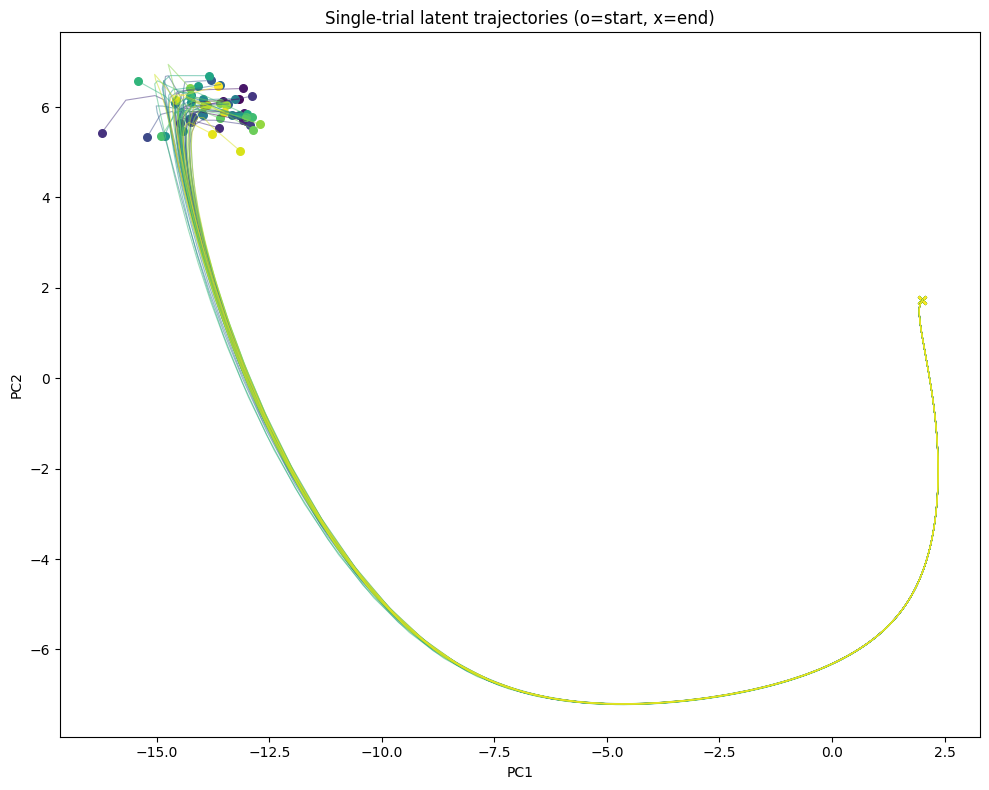

In [14]:
# 2D trajectories - single trials
fig, ax = plt.subplots(figsize=(10, 8))

n_show = min(50, n_trials)
colors = plt.cm.viridis(np.linspace(0, 1, n_show))

for i in range(n_show):
    traj = factors_pca[i]
    ax.plot(traj[:, 0], traj[:, 1], alpha=0.5, c=colors[i], lw=0.8)
    ax.scatter(traj[0, 0], traj[0, 1], c=[colors[i]], s=30, marker='o')  # start
    ax.scatter(traj[-1, 0], traj[-1, 1], c=[colors[i]], s=30, marker='x')  # end

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Single-trial latent trajectories (o=start, x=end)')
plt.tight_layout()

In [15]:
# Interactive 3D trajectories using Plotly
import plotly.graph_objs as go
import plotly.io as pio

fig = go.Figure()

for i in range(n_show):
    traj = factors_pca[i]
    fig.add_trace(go.Scatter3d(
        x=traj[:25, 0],
        y=traj[:25, 1],
        z=traj[:25, 2],
        mode='lines+markers',
        line=dict(color='rgba({}, {}, {}, 0.5)'.format(*(np.array(colors[i][:3])*255).astype(int))),
        marker=dict(size=2),
        name=f'Trial {i+1}',
        showlegend=False
    ))
    # Start point
    fig.add_trace(go.Scatter3d(
        x=[traj[0, 0]],
        y=[traj[0, 1]],
        z=[traj[0, 2]],
        mode='markers',
        marker=dict(size=5, color='green', symbol='circle'),
        name='Start' if i == 0 else None,
        showlegend=(i == 0)
    ))
    # End point
    fig.add_trace(go.Scatter3d(
        x=[traj[25, 0]],
        y=[traj[25, 1]],
        z=[traj[25, 2]],
        mode='markers',
        marker=dict(size=5, color='red', symbol='x'),
        name='End' if i == 0 else None,
        showlegend=(i == 0)
    ))

fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3',
    ),
    title='Interactive 3D latent trajectories (o=start, x=end)',
    width=1000,
    height=800,
    margin=dict(l=0, r=0, b=0, t=50),
)
fig.show()

In [7]:
fac_dim

8

## 2. Factor time courses (individual factors over time)

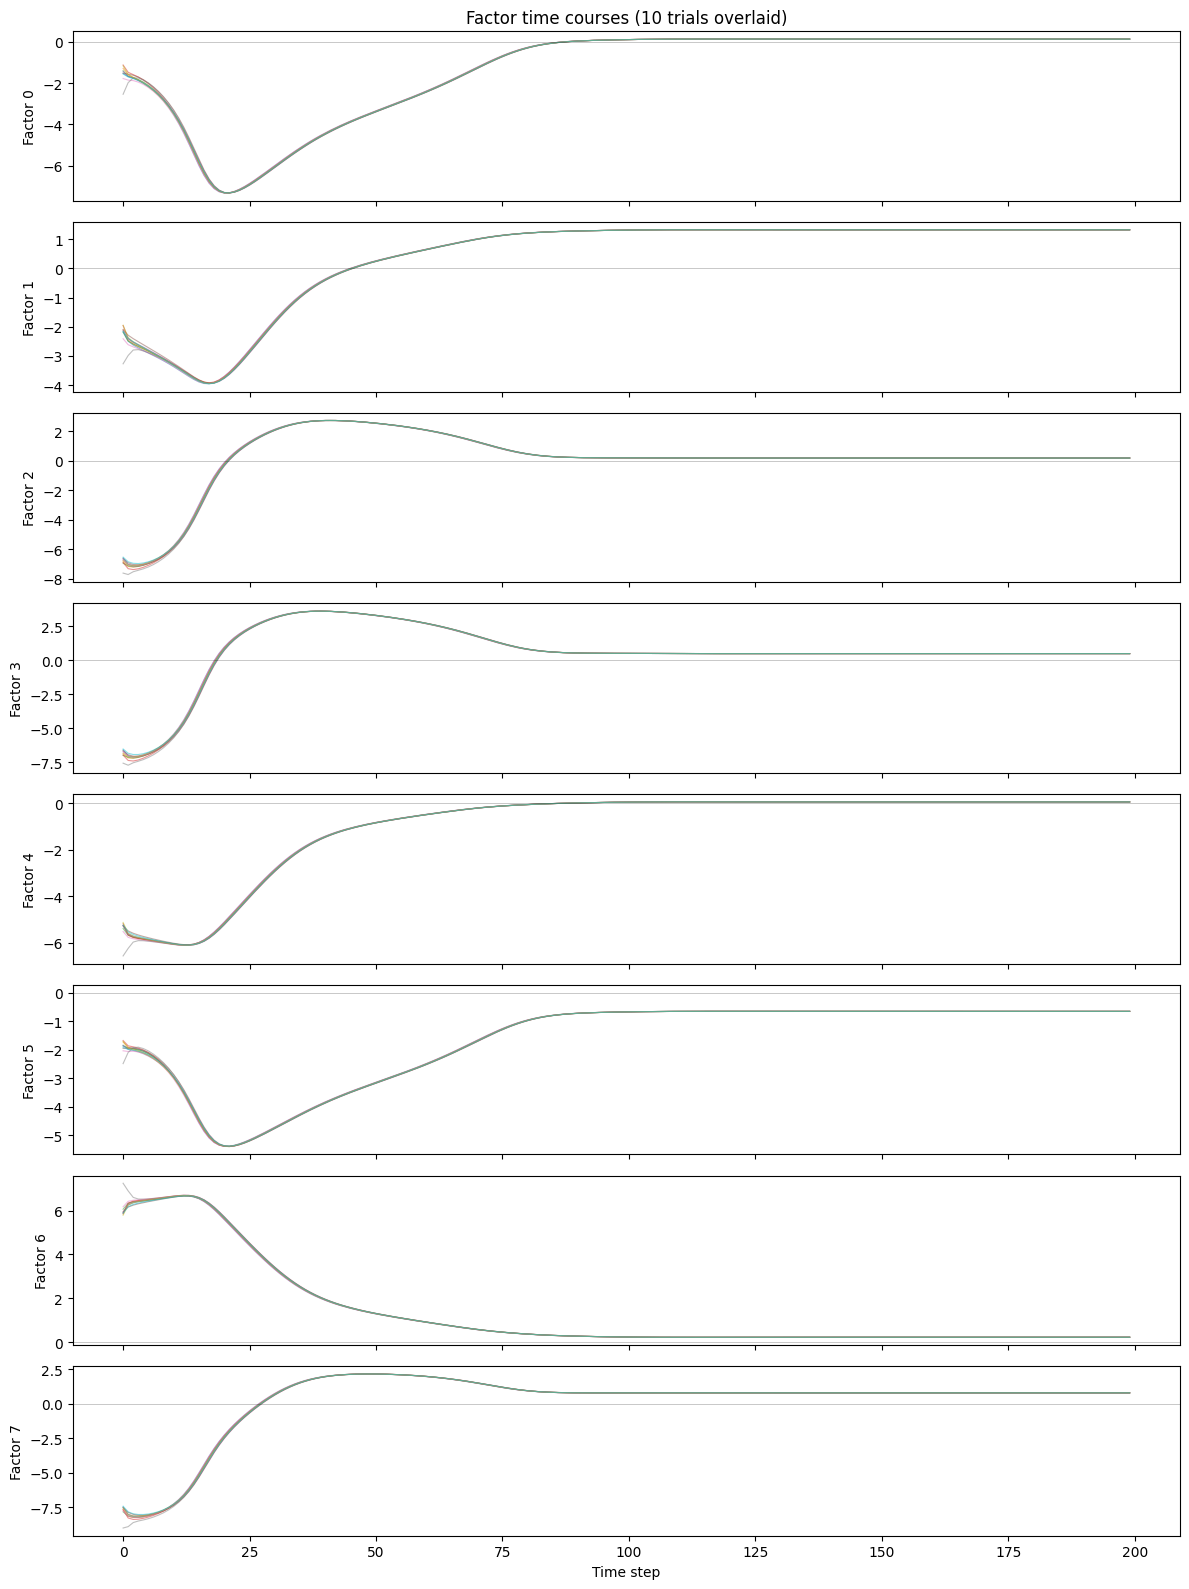

In [16]:
# Plot individual factor time courses for several trials
n_factors_show = min(64, fac_dim)
n_trials_show = 10

fig, axes = plt.subplots(n_factors_show, 1, figsize=(12, 2*n_factors_show), sharex=True)

for f_idx in range(n_factors_show):
    ax = axes[f_idx]
    for t_idx in range(n_trials_show):
        ax.plot(factors[t_idx, :, f_idx], alpha=0.5, lw=0.8)
    ax.set_ylabel(f'Factor {f_idx}')
    ax.axhline(0, c='k', lw=0.5, alpha=0.3)

axes[-1].set_xlabel('Time step')
axes[0].set_title('Factor time courses (10 trials overlaid)')
plt.tight_layout()

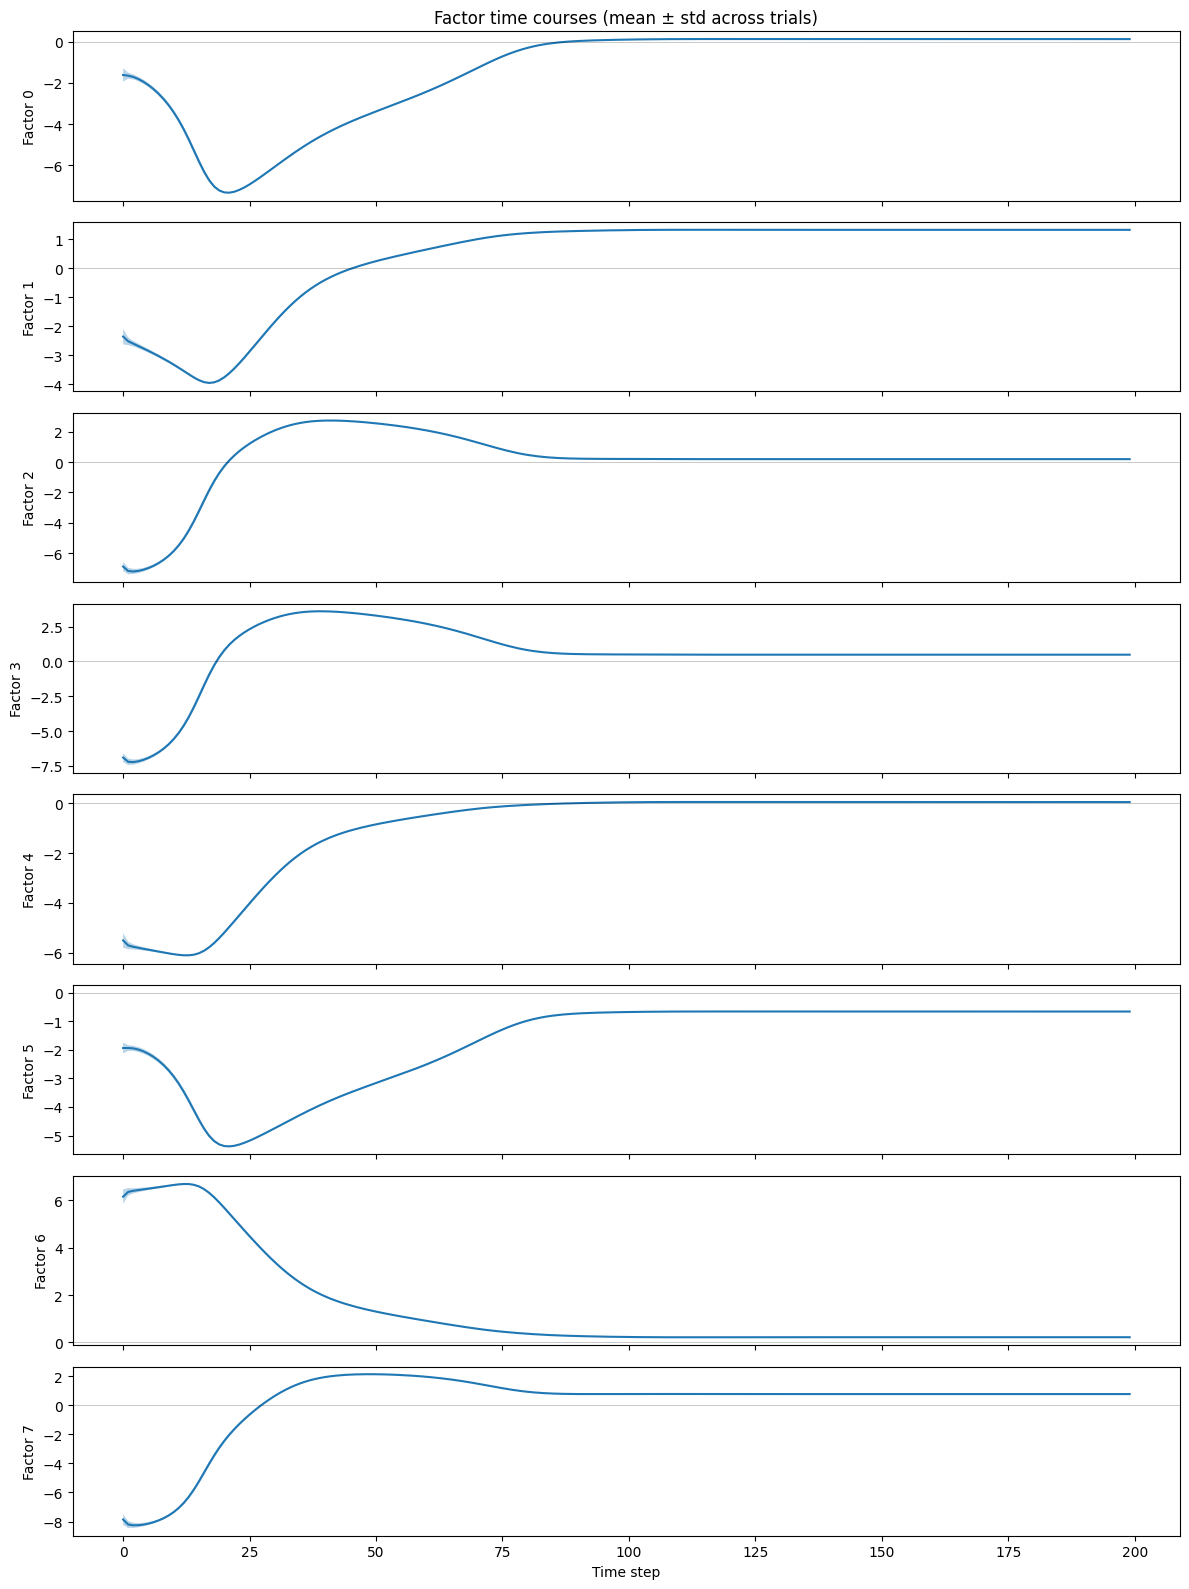

In [17]:
# Mean +/- std across trials
fig, axes = plt.subplots(n_factors_show, 1, figsize=(12, 2*n_factors_show), sharex=True)

for f_idx in range(n_factors_show):
    ax = axes[f_idx]
    mean = factors[:, :, f_idx].mean(axis=0)
    std = factors[:, :, f_idx].std(axis=0)
    t = np.arange(seq_len)
    ax.plot(t, mean, c='C0')
    ax.fill_between(t, mean - std, mean + std, alpha=0.3)
    ax.set_ylabel(f'Factor {f_idx}')
    ax.axhline(0, c='k', lw=0.5, alpha=0.3)

axes[-1].set_xlabel('Time step')
axes[0].set_title('Factor time courses (mean ± std across trials)')
plt.tight_layout()

## 3. Initial conditions

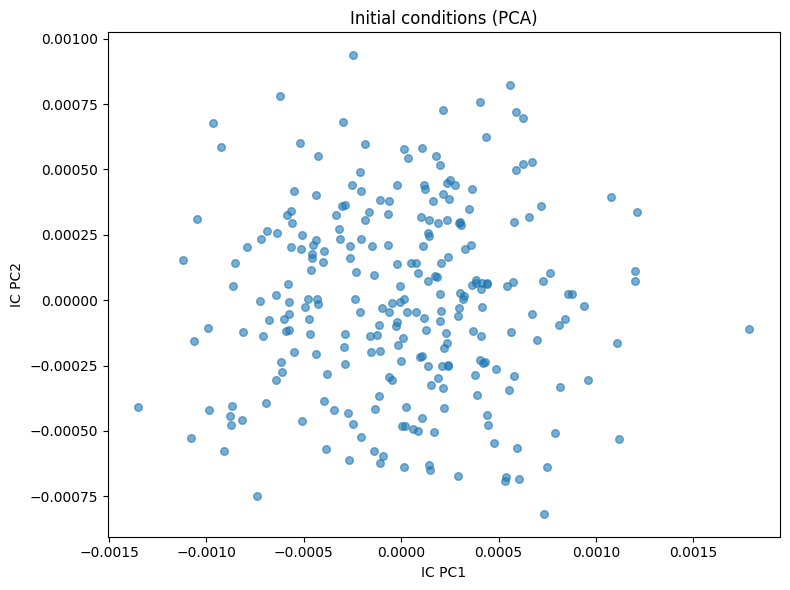

In [18]:
# PCA on initial conditions
pca_ic = PCA(n_components=2)
ics_pca = pca_ic.fit_transform(ics)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(ics_pca[:, 0], ics_pca[:, 1], alpha=0.6, s=30)
ax.set_xlabel('IC PC1')
ax.set_ylabel('IC PC2')
ax.set_title('Initial conditions (PCA)')
plt.tight_layout()

## 4. Speed along trajectory

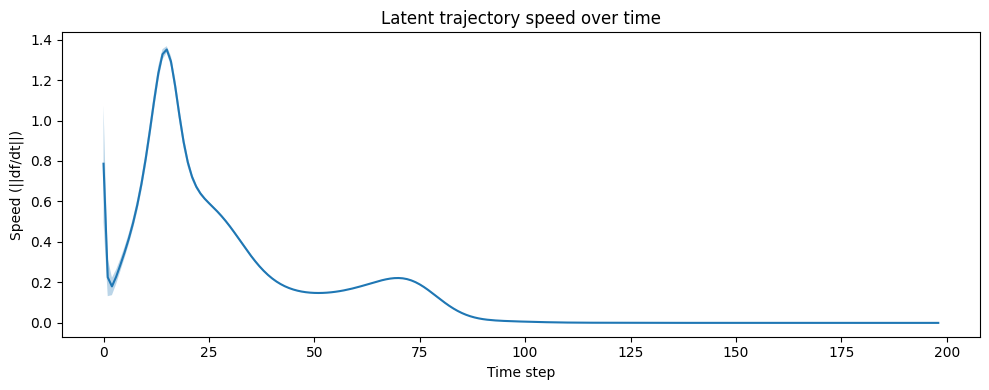

In [19]:
# Compute speed (norm of velocity) in latent space
velocities = np.diff(factors, axis=1)  # (n_trials, seq_len-1, fac_dim)
speeds = np.linalg.norm(velocities, axis=2)  # (n_trials, seq_len-1)

fig, ax = plt.subplots(figsize=(10, 4))
mean_speed = speeds.mean(axis=0)
std_speed = speeds.std(axis=0)
t = np.arange(len(mean_speed))

ax.plot(t, mean_speed, c='C0')
ax.fill_between(t, mean_speed - std_speed, mean_speed + std_speed, alpha=0.3)
ax.set_xlabel('Time step')
ax.set_ylabel('Speed (||df/dt||)')
ax.set_title('Latent trajectory speed over time')
plt.tight_layout()

## 5. Trajectory colored by time

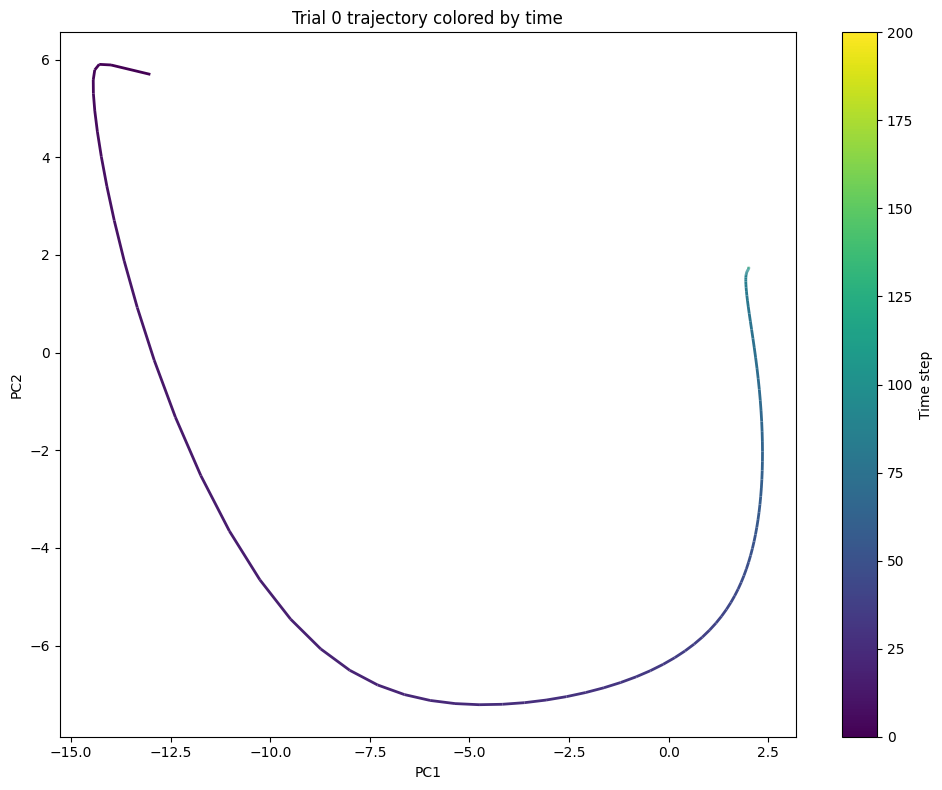

In [20]:
# Single trajectory colored by time
trial_idx = 0
traj = factors_pca[trial_idx]

fig, ax = plt.subplots(figsize=(10, 8))
points = traj[:, :2].reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

from matplotlib.collections import LineCollection
norm = plt.Normalize(0, seq_len)
lc = LineCollection(segments, cmap='viridis', norm=norm)
lc.set_array(np.arange(seq_len))
lc.set_linewidth(2)
line = ax.add_collection(lc)
fig.colorbar(line, ax=ax, label='Time step')

ax.autoscale()
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'Trial {trial_idx} trajectory colored by time')
plt.tight_layout()